# EDA: датасет сегментации пневмоторакса

Этот ноутбук предназначен для **разведочного анализа данных (EDA)**.

Что делает ноутбук:
- показывает баланс классов;
- показывает распределение размеров масок;
- визуализирует несколько пар `image + mask`;
- воспроизводит train/val split так же, как в проекте.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = (PROJECT_ROOT / "..").resolve()

assert (PROJECT_ROOT / "src").exists(), f"Не найден src/ относительно {PROJECT_ROOT}"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = /home/jupyter/project


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

from src.utils.config import load_yaml
from src.data.utils import build_metadata_dataframe, filter_by_mask_coverage, summarize_dataframe


In [3]:
CONFIG_CANDIDATES = [
    PROJECT_ROOT / "configs" / "training_unet.yaml",
    PROJECT_ROOT / "configs" / "training_transformer_unet.yaml",
    PROJECT_ROOT / "configs" / "training_attention_unet.yaml",
]

CONFIG_PATH = next((p for p in CONFIG_CANDIDATES if p.exists()), None)
assert CONFIG_PATH is not None, "Не найден ни один training config в папке configs/"

config = load_yaml(CONFIG_PATH)
print("CONFIG_PATH =", CONFIG_PATH)
config


CONFIG_PATH = /home/jupyter/project/configs/training_unet.yaml


{'seed': 42,
 'paths': {'train_csv_path': 'data/stage_1_train_images.csv',
  'test_csv_path': 'data/stage_1_test_images.csv',
  'images_dir': 'data/png_images',
  'masks_dir': 'data/png_masks',
  'artifacts_dir': 'artifacts/unet_positive_tversky'},
 'data': {'image_size': 256,
  'batch_size': 8,
  'num_workers': 0,
  'positive_only': True,
  'min_mask_coverage': 0.005,
  'val_size': 0.15,
  'test_size': 0.15,
  'drop_missing_positive_masks': True,
  'num_prediction_examples': 8,
  'prediction_examples_split': 'test',
  'prediction_examples_positive_only': True},
 'training': {'model_name': 'unet',
  'base_channels': 32,
  'loss_name': 'tversky',
  'learning_rate': 0.0001,
  'weight_decay': 1e-05,
  'num_epochs': 200,
  'threshold': 0.5,
  'threshold_candidates': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
  'scheduler_factor': 0.5,
  'scheduler_patience': 3,
  'mixed_precision': True,
  'early_stopping_patience': 15,
  'device': 'cuda'}}

In [4]:
paths = config["paths"]
data_cfg = config["data"]
training_cfg = config["training"]

train_csv_path = PROJECT_ROOT / paths.get("train_csv_path", paths.get("csv_path"))
test_csv_path = PROJECT_ROOT / paths.get("test_csv_path", "")
images_dir = PROJECT_ROOT / paths["images_dir"]
masks_dir = PROJECT_ROOT / paths["masks_dir"]

print("train_csv_path =", train_csv_path)
print("test_csv_path  =", test_csv_path if str(test_csv_path) else None)
print("images_dir     =", images_dir)
print("masks_dir      =", masks_dir)
print("positive_only  =", data_cfg.get("positive_only", False))
print("min_mask_coverage =", data_cfg.get("min_mask_coverage", 0.0))


train_csv_path = /home/jupyter/project/data/stage_1_train_images.csv
test_csv_path  = /home/jupyter/project/data/stage_1_test_images.csv
images_dir     = /home/jupyter/project/data/png_images
masks_dir      = /home/jupyter/project/data/png_masks
positive_only  = True
min_mask_coverage = 0.005


In [5]:
drop_missing_positive_masks = bool(data_cfg.get("drop_missing_positive_masks", True))
min_mask_coverage = float(data_cfg.get("min_mask_coverage", 0.0))
positive_only = bool(data_cfg.get("positive_only", False))

train_df_raw = build_metadata_dataframe(
    csv_path=train_csv_path,
    images_dir=images_dir,
    masks_dir=masks_dir,
    drop_missing_positive_masks=drop_missing_positive_masks,
)

test_df_raw = None
if str(test_csv_path) and Path(test_csv_path).exists():
    test_df_raw = build_metadata_dataframe(
        csv_path=test_csv_path,
        images_dir=images_dir,
        masks_dir=masks_dir,
        drop_missing_positive_masks=drop_missing_positive_masks,
    )

print("train_df_raw:", len(train_df_raw))
print("test_df_raw :", len(test_df_raw) if test_df_raw is not None else "нет внешнего test")


train_df_raw: 3008
test_df_raw : 1372


In [6]:
def apply_training_filters(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if positive_only and "has_pneumo" in df.columns:
        df = df[df["has_pneumo"] == 1].reset_index(drop=True)
    df = filter_by_mask_coverage(df, min_coverage=min_mask_coverage)
    return df.reset_index(drop=True)

train_df = apply_training_filters(train_df_raw)
test_df = apply_training_filters(test_df_raw) if test_df_raw is not None else None

print("train_df after filters:", len(train_df))
print("test_df after filters :", len(test_df) if test_df is not None else "нет внешнего test")


train_df after filters: 1107
test_df after filters : 209


In [7]:
print("=== RAW TRAIN SUMMARY ===")
print(summarize_dataframe(train_df_raw))
if test_df_raw is not None:
    print("\n=== RAW TEST SUMMARY ===")
    print(summarize_dataframe(test_df_raw))

print("\n=== FILTERED TRAIN SUMMARY ===")
print(summarize_dataframe(train_df))
if test_df is not None:
    print("\n=== FILTERED TEST SUMMARY ===")
    print(summarize_dataframe(test_df))


=== RAW TRAIN SUMMARY ===
{'num_samples': 3008, 'num_positive': 1693, 'num_negative': 1315, 'positive_ratio': 0.5628324468085106}

=== RAW TEST SUMMARY ===
{'num_samples': 1372, 'num_positive': 290, 'num_negative': 1082, 'positive_ratio': 0.21137026239067055}

=== FILTERED TRAIN SUMMARY ===
{'num_samples': 1107, 'num_positive': 1107, 'num_negative': 0, 'positive_ratio': 1.0}

=== FILTERED TEST SUMMARY ===
{'num_samples': 209, 'num_positive': 209, 'num_negative': 0, 'positive_ratio': 1.0}


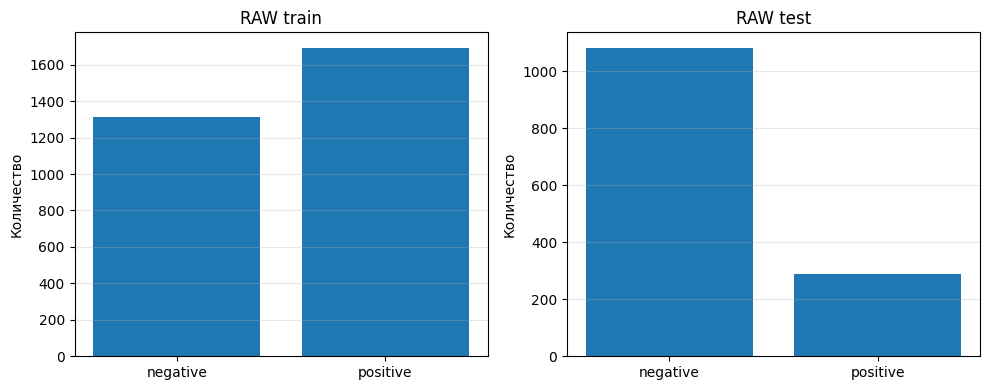

In [8]:
fig, axes = plt.subplots(1, 2 if test_df_raw is not None else 1, figsize=(10, 4))

def plot_class_balance(ax, df, title):
    if df is None or "has_pneumo" not in df.columns:
        ax.set_title(title)
        ax.text(0.5, 0.5, "Нет данных", ha="center", va="center")
        ax.axis("off")
        return
    counts = df["has_pneumo"].value_counts().sort_index()
    labels = ["negative" if idx == 0 else "positive" for idx in counts.index]
    ax.bar(labels, counts.values)
    ax.set_title(title)
    ax.set_ylabel("Количество")
    ax.grid(True, axis="y", alpha=0.3)

if test_df_raw is not None:
    plot_class_balance(axes[0], train_df_raw, "RAW train")
    plot_class_balance(axes[1], test_df_raw, "RAW test")
else:
    plot_class_balance(axes, train_df_raw, "RAW train")

plt.tight_layout()
plt.show()


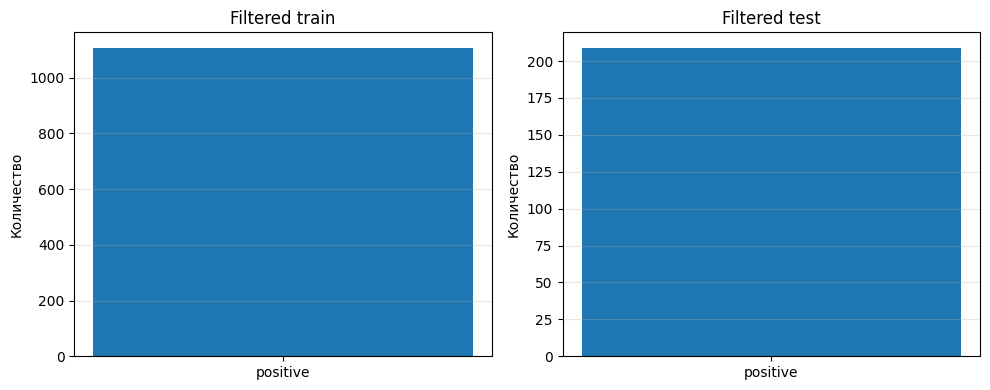

In [9]:
fig, axes = plt.subplots(1, 2 if test_df is not None else 1, figsize=(10, 4))

if test_df is not None:
    plot_class_balance(axes[0], train_df, "Filtered train")
    plot_class_balance(axes[1], test_df, "Filtered test")
else:
    plot_class_balance(axes, train_df, "Filtered train")

plt.tight_layout()
plt.show()


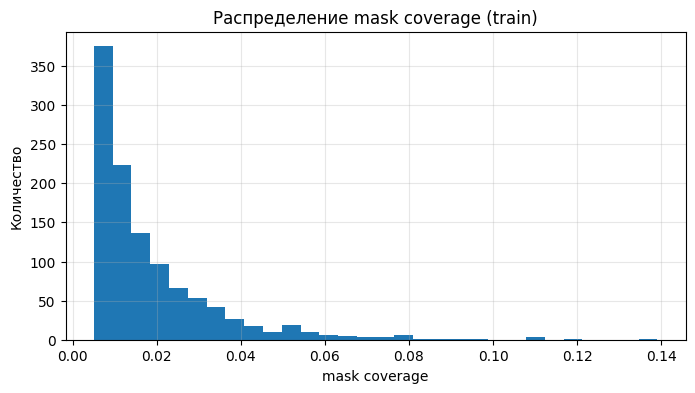

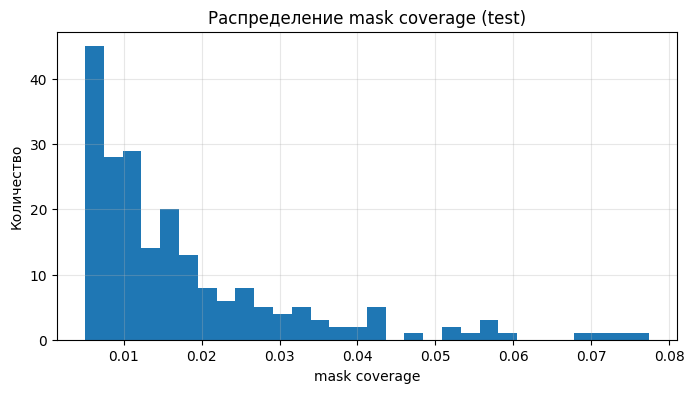

In [10]:
coverage_col = "mask_coverage" if "mask_coverage" in train_df.columns else None
if coverage_col:
    plt.figure(figsize=(8, 4))
    plt.hist(train_df[coverage_col].dropna(), bins=30)
    plt.title("Распределение mask coverage (train)")
    plt.xlabel("mask coverage")
    plt.ylabel("Количество")
    plt.grid(True, alpha=0.3)
    plt.show()

    if test_df is not None and coverage_col in test_df.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(test_df[coverage_col].dropna(), bins=30)
        plt.title("Распределение mask coverage (test)")
        plt.xlabel("mask coverage")
        plt.ylabel("Количество")
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("Колонка mask_coverage не найдена: пропускаю гистограммы покрытия масок.")


In [11]:
def split_train_val_only(df: pd.DataFrame, val_size: float, seed: int = 42):
    stratify = df["has_pneumo"] if "has_pneumo" in df.columns and df["has_pneumo"].nunique() > 1 else None
    train_part, val_part = train_test_split(
        df,
        test_size=val_size,
        random_state=seed,
        stratify=stratify,
    )
    return train_part.reset_index(drop=True), val_part.reset_index(drop=True)

val_size = float(data_cfg.get("val_size", 0.15))
seed = int(config.get("seed", 42))

train_part, val_part = split_train_val_only(train_df, val_size=val_size, seed=seed)
print("train_part:", len(train_part))
print("val_part  :", len(val_part))
print("test_df   :", len(test_df) if test_df is not None else "нет внешнего test")


train_part: 940
val_part  : 167
test_df   : 209


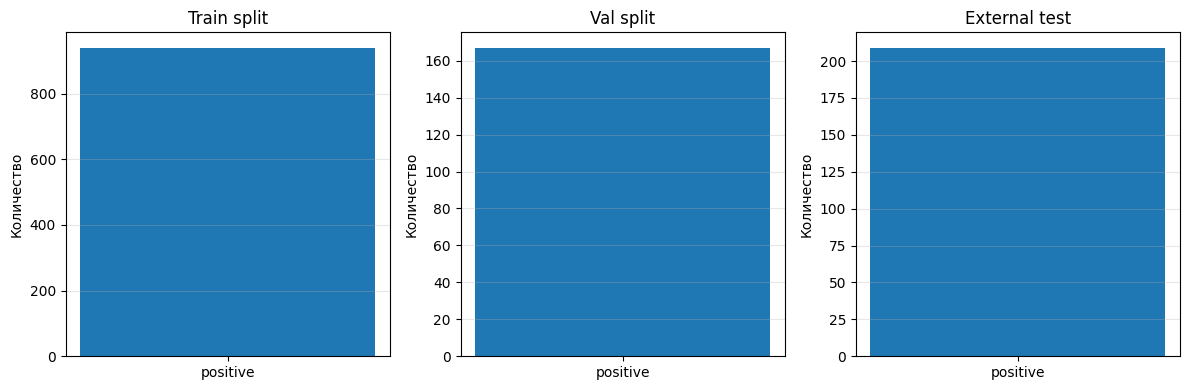

In [12]:
fig, axes = plt.subplots(1, 3 if test_df is not None else 2, figsize=(12, 4))

plot_class_balance(axes[0], train_part, "Train split")
plot_class_balance(axes[1], val_part, "Val split")
if test_df is not None:
    plot_class_balance(axes[2], test_df, "External test")

plt.tight_layout()
plt.show()


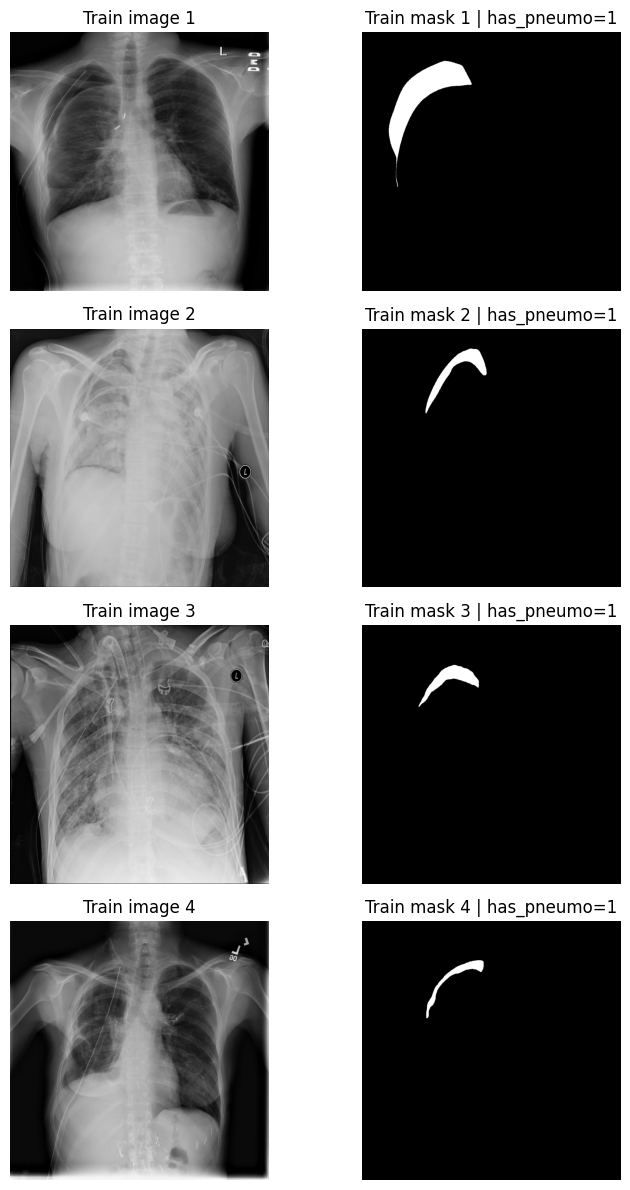

In [13]:
def show_examples(df: pd.DataFrame, n: int = 4, title_prefix: str = ""):
    if df is None or len(df) == 0:
        print("Нет примеров для отображения.")
        return

    sample_df = df.sample(min(n, len(df)), random_state=42).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample_df), 2, figsize=(8, 3 * len(sample_df)))
    if len(sample_df) == 1:
        axes = np.array([axes])

    for i, row in sample_df.iterrows():
        image = Image.open(row["image_path"]).convert("L")
        mask_path = row.get("mask_path")
        if isinstance(mask_path, str) and Path(mask_path).exists():
            mask = Image.open(mask_path).convert("L")
        else:
            mask = Image.fromarray(np.zeros((image.height, image.width), dtype=np.uint8), mode="L")

        axes[i, 0].imshow(image, cmap="gray")
        axes[i, 0].set_title(f"{title_prefix} image {i+1}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        label = row["has_pneumo"] if "has_pneumo" in row else "?"
        axes[i, 1].set_title(f"{title_prefix} mask {i+1} | has_pneumo={label}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_examples(train_part, n=4, title_prefix="Train")
